In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from scipy.linalg import lstsq

import math
%matplotlib inline

from scipy.interpolate import interp1d

from statsmodels.stats.multicomp import pairwise_tukeyhsd

import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
df = pd.read_csv("../Data/Q_PMETobs_1950_2020_v10d.csv")

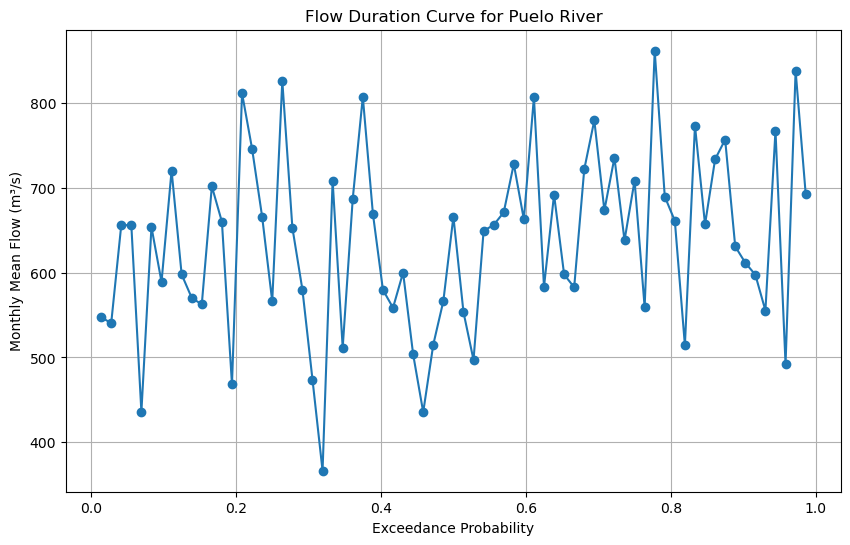

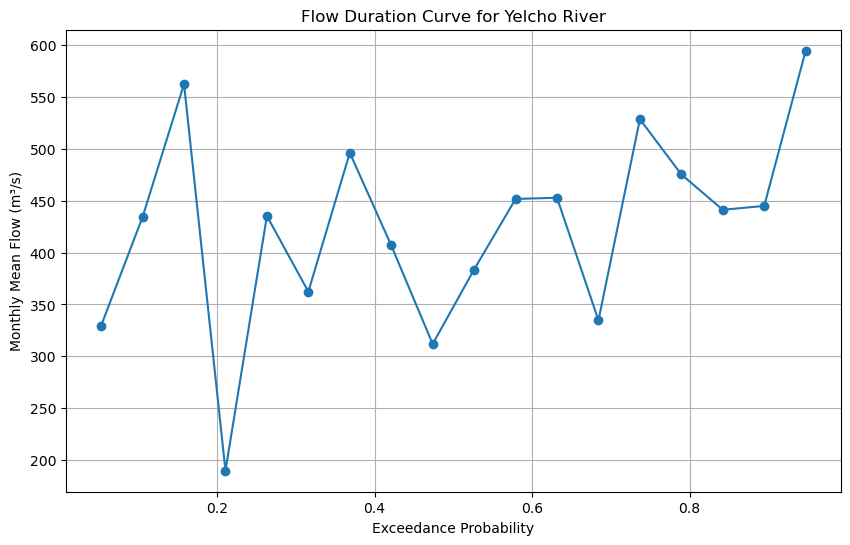

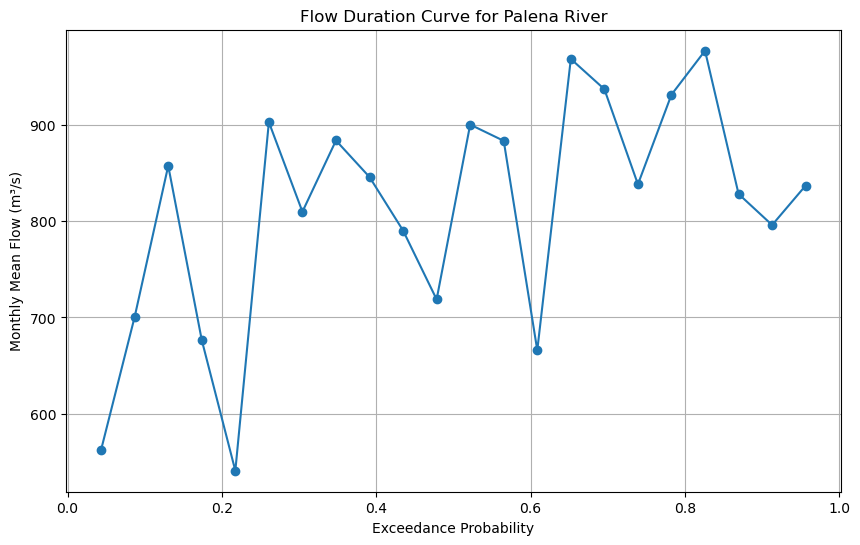

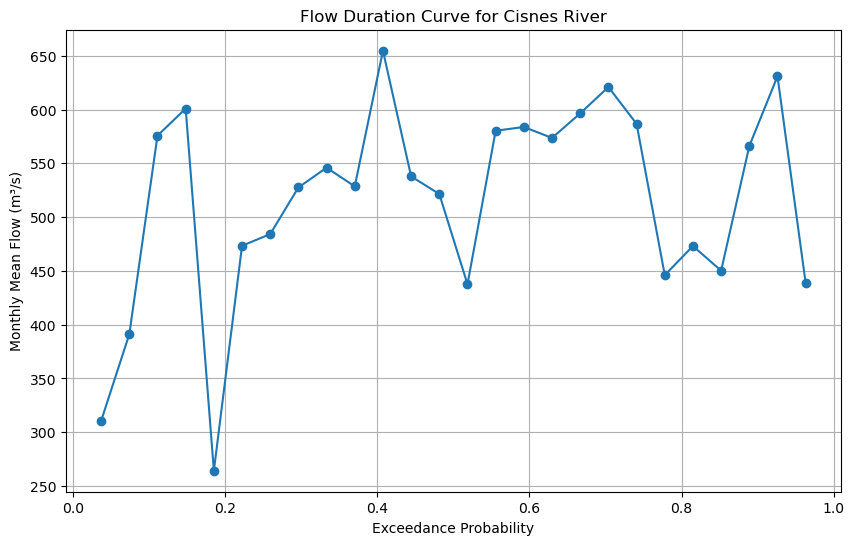

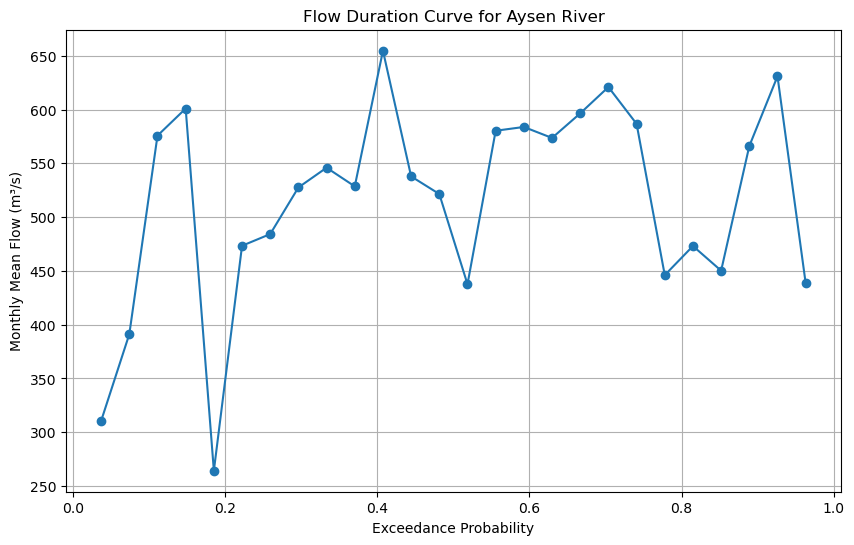

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def weibull_plotting_position(data):
    """Calculate Weibull plotting position for given data."""
    n = len(data)
    ranks = np.arange(1, n + 1)
    weibull_pp = (n + 1 - ranks) / (n + 1)
    return weibull_pp

# Load the data from the CSV file
file_path = "../Data/Q_PMETobs_1950_2020_v10d.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])

# Extract only the columns for the rivers of interest
rivers_of_interest = ["X10523002", "X10704002", "X11040001", "X11342001", "X11342001"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Group data by river and month, and calculate the mean streamflow for each month
monthly_mean_flow = pd.DataFrame()
for river_code in rivers_of_interest:
    river_data = data[['Date', river_code]].copy()  # Create a copy of the DataFrame
    river_data.set_index('Date', inplace=True)
    monthly_mean_flow_river = river_data.groupby([river_data.index.year, river_data.index.month])[river_code].mean().reset_index(level=1, drop=True).groupby('Date').mean()
    monthly_mean_flow[river_code] = monthly_mean_flow_river

# Calculate Weibull plotting position for each river
weibull_pp = {}
for river_code in rivers_of_interest:
    monthly_mean_flow_river = monthly_mean_flow[river_code].dropna()
    weibull_pp[river_code] = weibull_plotting_position(monthly_mean_flow_river)

# Plot flow duration curve for each river
for river_code, river_name in zip(rivers_of_interest, river_names):
    plt.figure(figsize=(10, 6))
    plt.plot(weibull_pp[river_code], monthly_mean_flow[river_code].dropna(), marker='o', linestyle='-')
    plt.xlabel('Exceedance Probability')
    plt.ylabel('Monthly Mean Flow (m³/s)')
    plt.title(f'Flow Duration Curve for {river_name} River')
    plt.grid(True)
    plt.show()

Number of Months of Data Available:
Puelo: 840 months
Yelcho: 185 months
Palena: 241 months
Cisnes: 288 months
Aysen: 288 months


/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_18363/3855892424.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  num_months = len(river_data.resample('M').mean().dropna())
/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_18363/3855892424.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  num_months = len(river_data.resample('M').mean().dropna())
/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_18363/3855892424.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  num_months = len(river_data.resample('M').mean().dropna())
/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_18363/3855892424.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  num_months = len(river_data.resample('M').mean().dropna())
/var/folders/x8/mpvljg_94_nb

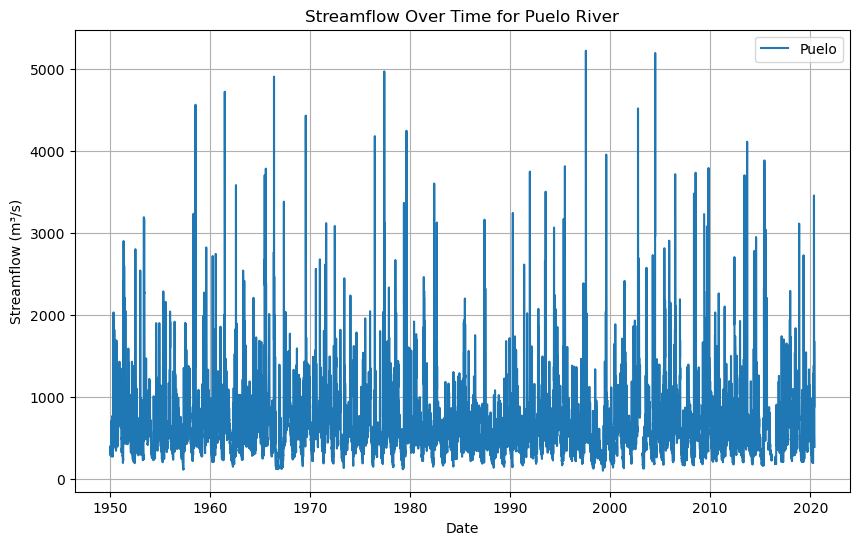

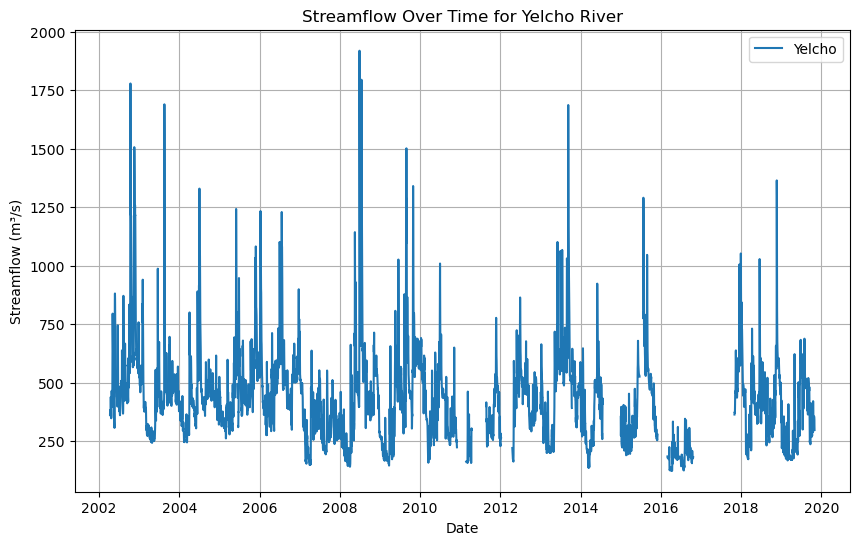

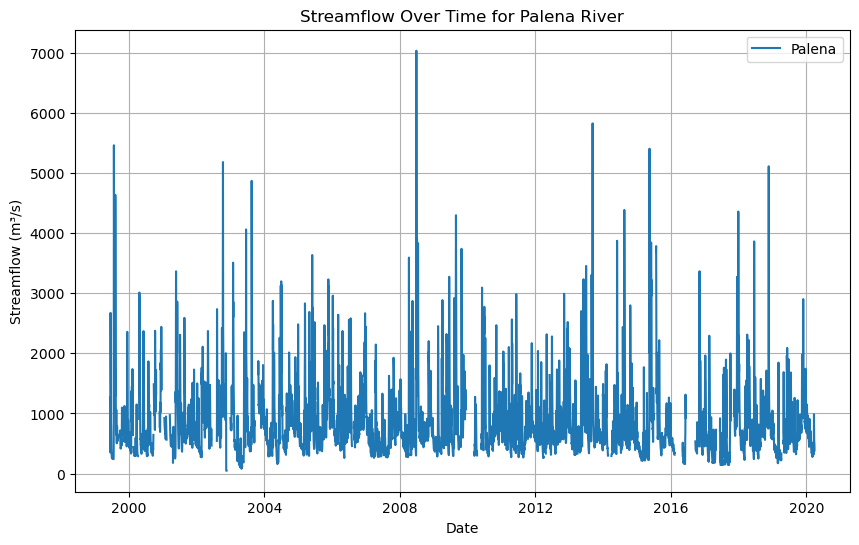

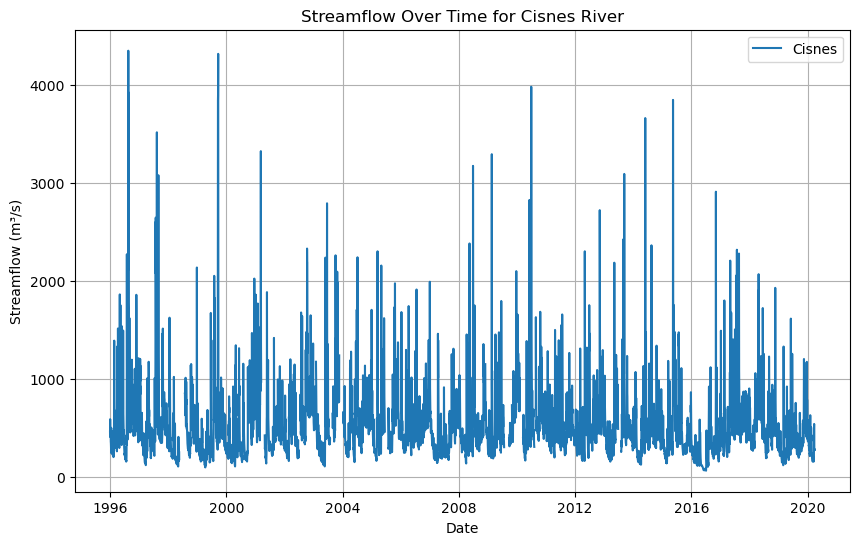

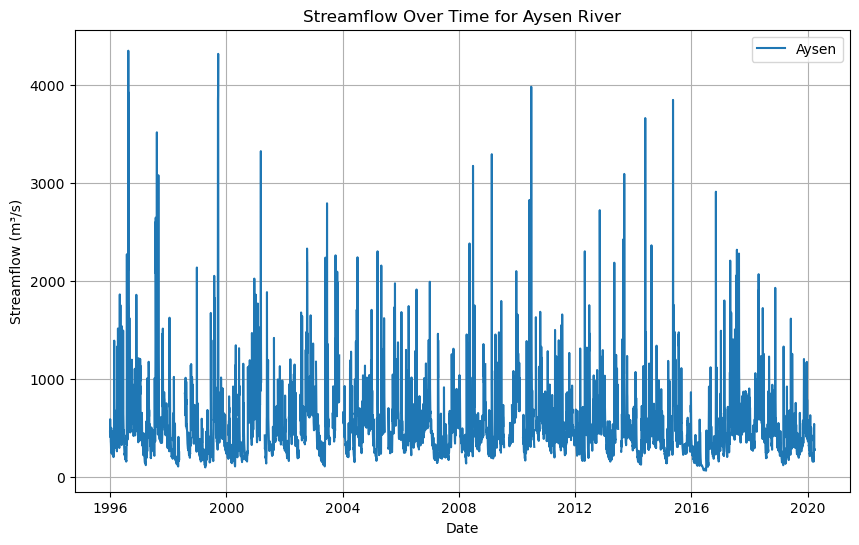

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the CSV file
file_path = "../Data/Q_PMETobs_1950_2020_v10d.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])

# Extract only the columns for the rivers of interest
rivers_of_interest = ["X10523002", "X10704002", "X11040001", "X11342001", "X11342001"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Print the number of months of data available for each river
print("Number of Months of Data Available:")
for river_code, river_name in zip(rivers_of_interest, river_names):
    river_data = data[['Date', river_code]].copy()  # Create a copy of the DataFrame
    river_data.set_index('Date', inplace=True)
    num_months = len(river_data.resample('M').mean().dropna())
    print(f"{river_name}: {num_months} months")

# Plot streamflow over time for each river
for river_code, river_name in zip(rivers_of_interest, river_names):
    plt.figure(figsize=(10, 6))
    river_data = data[['Date', river_code]].copy()  # Create a copy of the DataFrame
    river_data.set_index('Date', inplace=True)
    plt.plot(river_data.index, river_data[river_code], label=river_name)
    plt.xlabel('Date')
    plt.ylabel('Streamflow (m³/s)')
    plt.title(f'Streamflow Over Time for {river_name} River')
    plt.legend()
    plt.grid(True)
    plt.show()

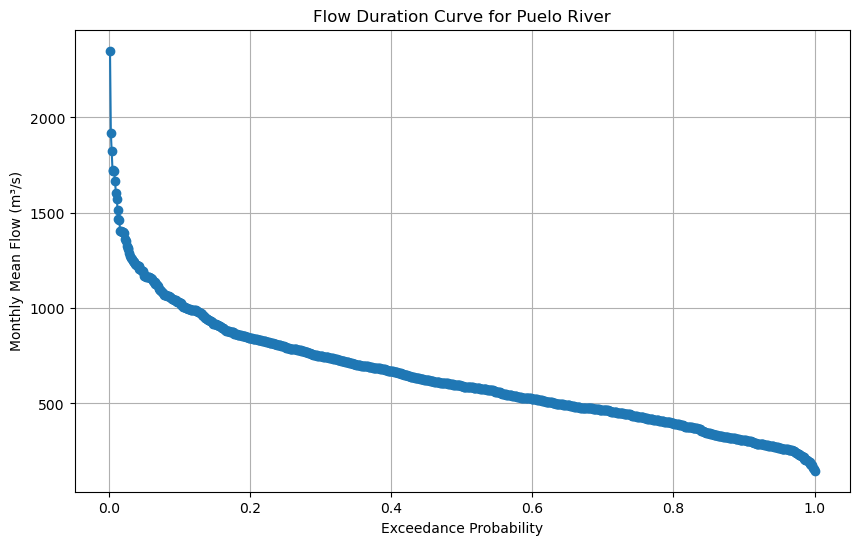

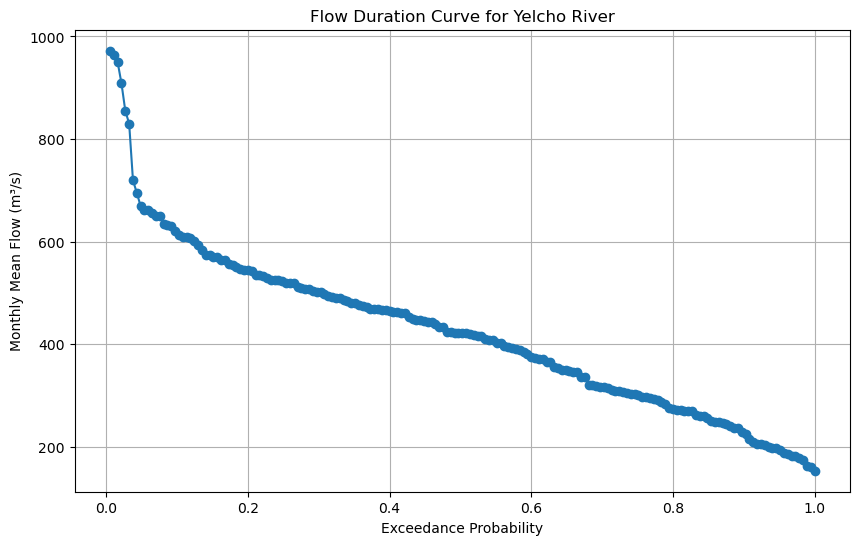

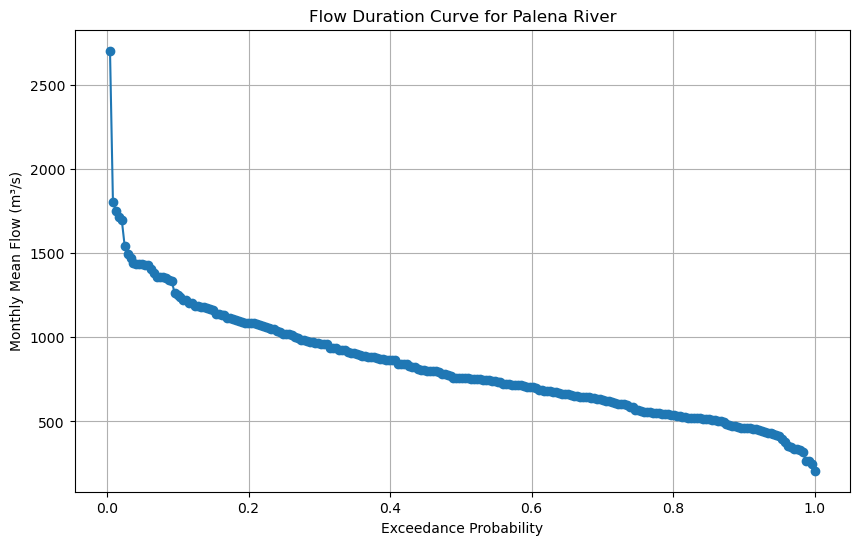

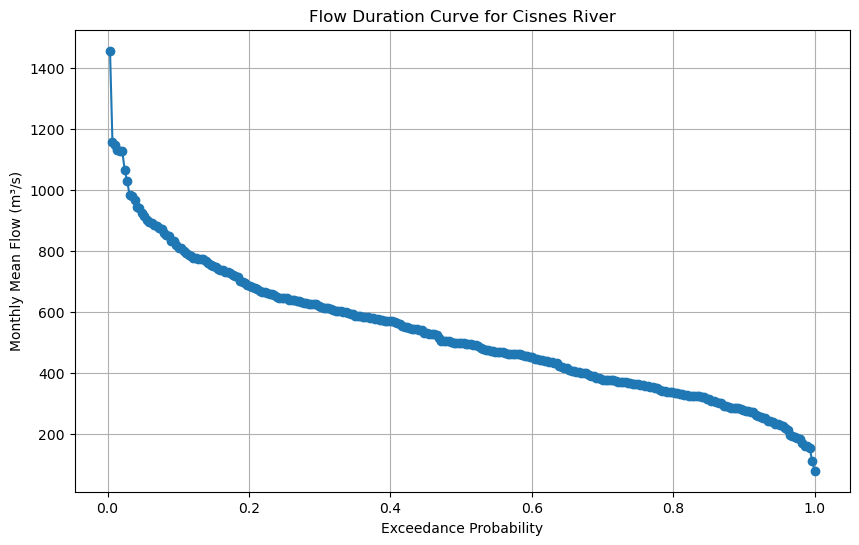

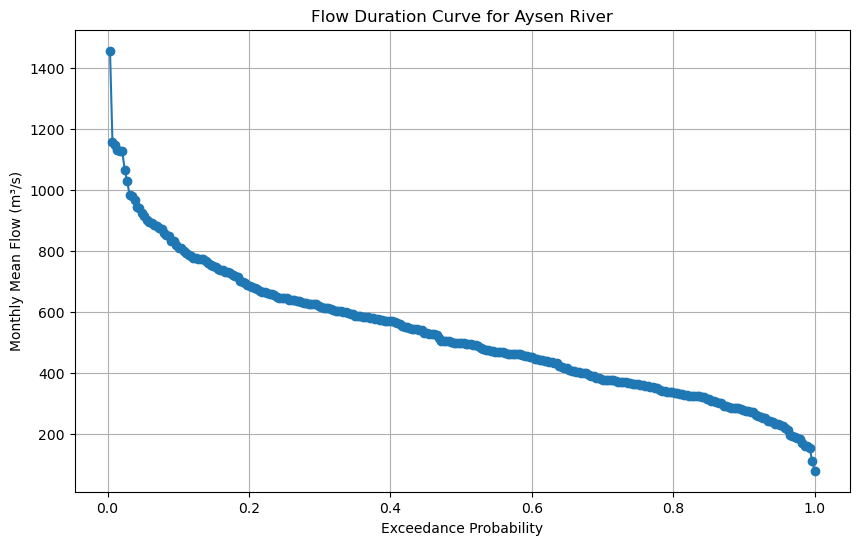

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the CSV file
file_path = "../Data/Q_PMETobs_1950_2020_v10d.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])

# Extract only the columns for the rivers of interest
rivers_of_interest = ["X10523002", "X10704002", "X11040001", "X11342001", "X11342001"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a DataFrame with complete date range covering the entire time span of the data
date_range = pd.date_range(start=data['Date'].min(), end=data['Date'].max(), freq='D')
complete_data = pd.DataFrame({'Date': date_range})
complete_data.set_index('Date', inplace=True)

# Merge the complete DataFrame with the original data for each river
monthly_mean_flow = pd.DataFrame()
for river_code, river_name in zip(rivers_of_interest, river_names):
    river_data = data[['Date', river_code]].copy()  # Create a copy of the DataFrame
    river_data.set_index('Date', inplace=True)
    merged_data = complete_data.merge(river_data, how='left', left_index=True, right_index=True)
    merged_data.rename(columns={river_code: river_name}, inplace=True)
    
    # Calculate flow duration curve for each river
    flow_values = merged_data.groupby([merged_data.index.year, merged_data.index.month])[river_name].mean().dropna()
    sorted_flow_values = np.sort(flow_values)
    exceedance_probability = np.arange(1, len(flow_values) + 1) / len(flow_values)
    
    # Plot flow duration curve with reversed x-axis
    plt.figure(figsize=(10, 6))
    plt.plot(np.flip(exceedance_probability), sorted_flow_values, marker='o', linestyle='-')
    plt.xlabel('Exceedance Probability')
    plt.ylabel('Monthly Mean Flow (m³/s)')
    plt.title(f'Flow Duration Curve for {river_name} River')
    plt.grid(True)
    plt.show()


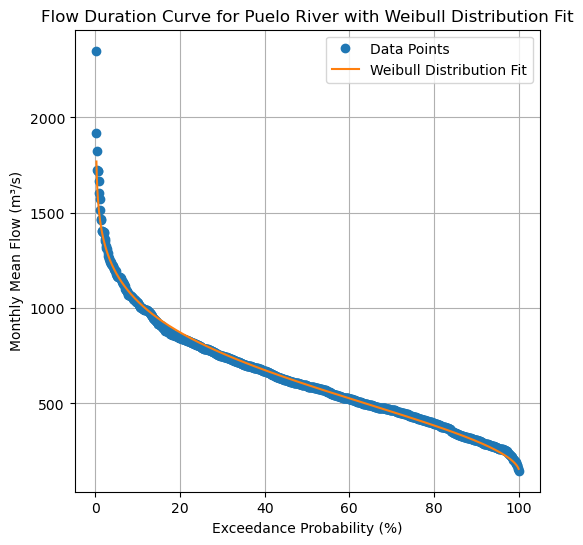

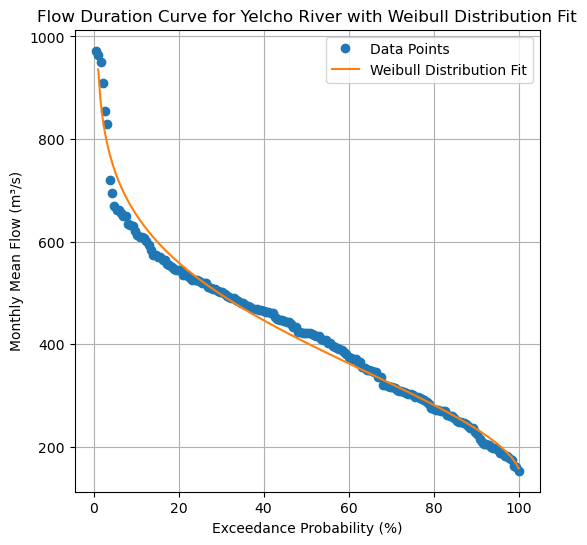

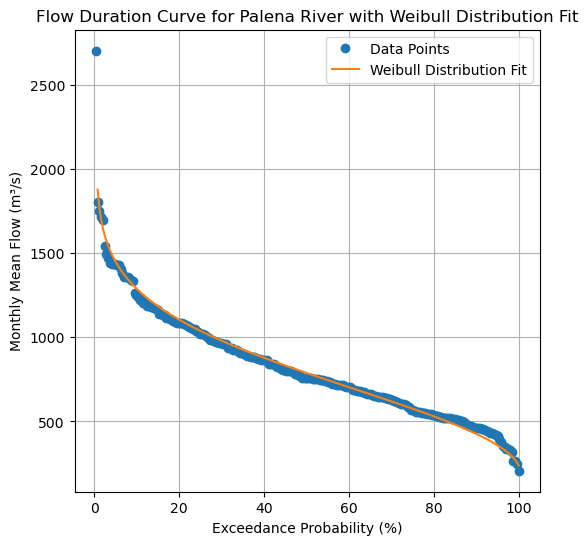

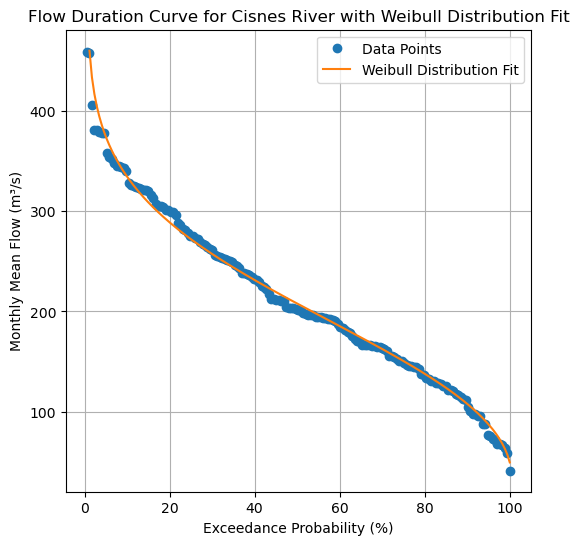

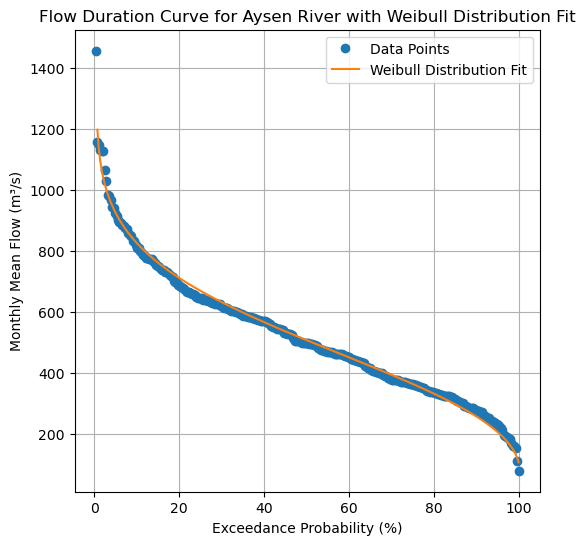

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the data from the CSV file
file_path = "../Data/Q_PMETobs_1950_2020_v10d.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])

# Extract only the columns for the rivers of interest
rivers_of_interest = ["X10523002", "X10704002", "X11040001", "X11147001", "X11342001"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a DataFrame with complete date range covering the entire time span of the data
date_range = pd.date_range(start=data['Date'].min(), end=data['Date'].max(), freq='D')
complete_data = pd.DataFrame({'Date': date_range})
complete_data.set_index('Date', inplace=True)

# Merge the complete DataFrame with the original data for each river
monthly_mean_flow = pd.DataFrame()
for river_code, river_name in zip(rivers_of_interest, river_names):
    river_data = data[['Date', river_code]].copy()  # Create a copy of the DataFrame
    river_data.set_index('Date', inplace=True)
    merged_data = complete_data.merge(river_data, how='left', left_index=True, right_index=True)
    merged_data.rename(columns={river_code: river_name}, inplace=True)
    
    # Calculate flow duration curve for each river
    flow_values = merged_data.groupby([merged_data.index.year, merged_data.index.month])[river_name].mean().dropna()
    sorted_flow_values = np.sort(flow_values)
    exceedance_probability = np.arange(1, len(flow_values) + 1) / len(flow_values)
    
    # Fit Weibull distribution to the data
    shape, loc, scale = stats.weibull_min.fit(sorted_flow_values, loc=0)
    weibull_fit = stats.weibull_min(shape, loc=loc, scale=scale)
    fitted_flow_values = weibull_fit.ppf(exceedance_probability)
    
    # Plot flow duration curve with fitted distribution
    plt.figure(figsize=(6, 6))
    plt.plot(np.flip(exceedance_probability) * 100, sorted_flow_values, marker='o', linestyle='', label='Data Points')
    plt.plot(np.flip(exceedance_probability) * 100, fitted_flow_values, label='Weibull Distribution Fit')
    plt.xlabel('Exceedance Probability (%)')
    plt.ylabel('Monthly Mean Flow (m³/s)')
    plt.title(f'Flow Duration Curve for {river_name} River with Weibull Distribution Fit')
    #plt.ylim(0, 2000)  # Set maximum y-axis value to 2000
    plt.legend()
    plt.grid(True)
    plt.show()


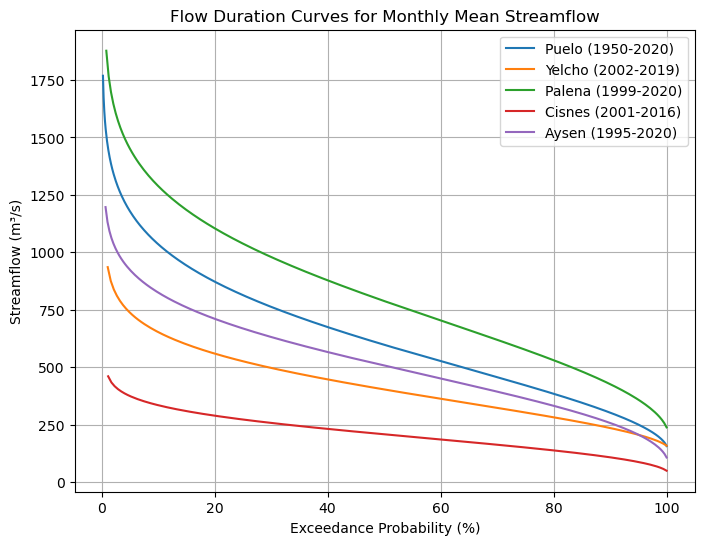

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the data from the CSV file
file_path = "../Data/Q_PMETobs_1950_2020_v10d.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])

# Extract only the columns for the rivers of interest
rivers_of_interest = ["X10523002", "X10704002", "X11040001", "X11147001", "X11342001"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a DataFrame with complete date range covering the entire time span of the data
date_range = pd.date_range(start=data['Date'].min(), end=data['Date'].max(), freq='D')
complete_data = pd.DataFrame({'Date': date_range})
complete_data.set_index('Date', inplace=True)

# Merge the complete DataFrame with the original data for each river
plt.figure(figsize=(8, 6))
legend_labels = []  # List to store legend labels with year ranges
for river_code, river_name in zip(rivers_of_interest, river_names):
    river_data = data[['Date', river_code]].copy()  # Create a copy of the DataFrame
    river_data.set_index('Date', inplace=True)
    merged_data = complete_data.merge(river_data, how='left', left_index=True, right_index=True)
    merged_data.rename(columns={river_code: river_name}, inplace=True)
    
    # Save the selected flow data to an Excel file
    #selected_flow_data = merged_data[[river_name]].dropna()
    #selected_flow_data.to_excel(f"{river_name}_flow_data.xlsx", index=True)
 
    # Find the year range with actual data (non-NaN values)
    valid_years = merged_data[river_name].dropna().index.year
    min_year = valid_years.min()
    max_year = valid_years.max()
    year_range = f"({min_year}-{max_year})" if not np.isnan(min_year) and not np.isnan(max_year) else "(No Data)"
    
    # Calculate flow duration curve for each river
    flow_values = merged_data.groupby([merged_data.index.year, merged_data.index.month])[river_name].mean().dropna()
    sorted_flow_values = np.sort(flow_values)
    exceedance_probability = np.arange(1, len(flow_values) + 1) / len(flow_values)
    
    # Fit Weibull distribution to the data
    shape, loc, scale = stats.weibull_min.fit(sorted_flow_values, loc=0)
    weibull_fit = stats.weibull_min(shape, loc=loc, scale=scale)
    fitted_flow_values = weibull_fit.ppf(exceedance_probability)
    
    # Plot only the line of best fit for each river
    plt.plot(np.flip(exceedance_probability) * 100, fitted_flow_values, label=f"{river_name} {year_range}")
    legend_labels.append(f"{river_name} {year_range}")  # Append legend label with year range

plt.xlabel('Exceedance Probability (%)')
plt.ylabel('Streamflow (m³/s)')
plt.title('Flow Duration Curves for Monthly Mean Streamflow')
plt.legend(labels=legend_labels)
plt.grid(True)
plt.show()

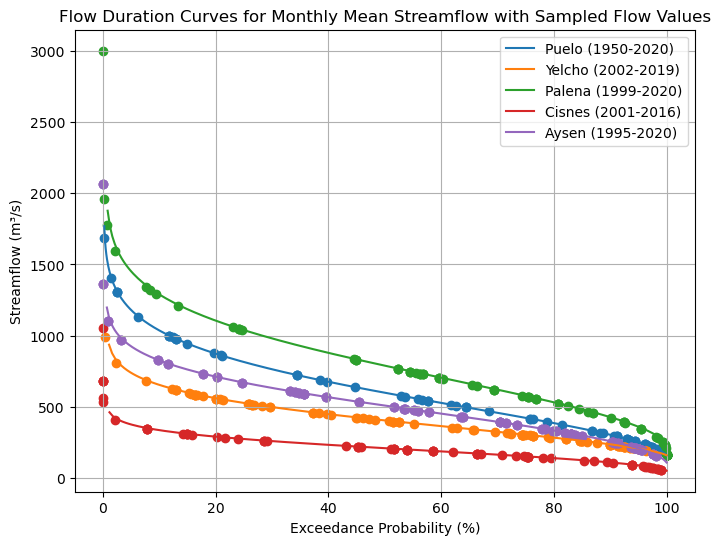

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the data from the CSV file
file_path = "../Data/Q_PMETobs_1950_2020_v10d.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])

# Extract only the columns for the rivers of interest
rivers_of_interest = ["X10523002", "X10704002", "X11040001", "X11147001", "X11342001"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a DataFrame with complete date range covering the entire time span of the data
date_range = pd.date_range(start=data['Date'].min(), end=data['Date'].max(), freq='D')
complete_data = pd.DataFrame({'Date': date_range})
complete_data.set_index('Date', inplace=True)

# Load the sampled data
sampled_data_path = "../Data/sampled_dates_flow_complete.xlsx"
sampled_data = pd.read_excel(sampled_data_path)

# Plot settings
plt.figure(figsize=(8, 6))
legend_handles = []  # List to store legend handles with line styles

for river_code, river_name in zip(rivers_of_interest, river_names):
    river_data = data[['Date', river_code]].copy()  # Create a copy of the DataFrame
    river_data.set_index('Date', inplace=True)
    merged_data = complete_data.merge(river_data, how='left', left_index=True, right_index=True)
    merged_data.rename(columns={river_code: river_name}, inplace=True)
    
    # Find the year range with actual data (non-NaN values)
    valid_years = merged_data[river_name].dropna().index.year
    min_year = valid_years.min()
    max_year = valid_years.max()
    year_range = f"({min_year}-{max_year})" if not np.isnan(min_year) and not np.isnan(max_year) else "(No Data)"
    
    # Calculate flow duration curve for each river
    flow_values = merged_data.groupby([merged_data.index.year, merged_data.index.month])[river_name].mean().dropna()
    sorted_flow_values = np.sort(flow_values)
    exceedance_probability = np.arange(1, len(flow_values) + 1) / len(flow_values)
    
    # Fit Weibull distribution to the data
    shape, loc, scale = stats.weibull_min.fit(sorted_flow_values, loc=0)
    weibull_fit = stats.weibull_min(shape, loc=loc, scale=scale)
    fitted_flow_values = weibull_fit.ppf(exceedance_probability)
    
    # Plot only the line of best fit for each river
    line, = plt.plot(np.flip(exceedance_probability) * 100, fitted_flow_values, label=f"{river_name} {year_range}")
    legend_handles.append(line)  # Append legend handle with line style
    
    # Plot sampled flow values on the Weibull distribution line
    sampled_river_data = sampled_data[sampled_data['River'] == river_name]
    for _, row in sampled_river_data.iterrows():
        x_value = 100 * (1 - stats.weibull_min.cdf(row['Flow'], shape, loc=loc, scale=scale))
        plt.scatter(x_value, row['Flow'], color=line.get_color())  # Use line color for sampled points

# Add separate legend entries for the Weibull distribution lines
plt.legend(handles=legend_handles)

plt.xlabel('Exceedance Probability (%)')
plt.ylabel('Streamflow (m³/s)')
plt.title('Flow Duration Curves for Monthly Mean Streamflow with Sampled Flow Values')
plt.grid(True)
plt.show()

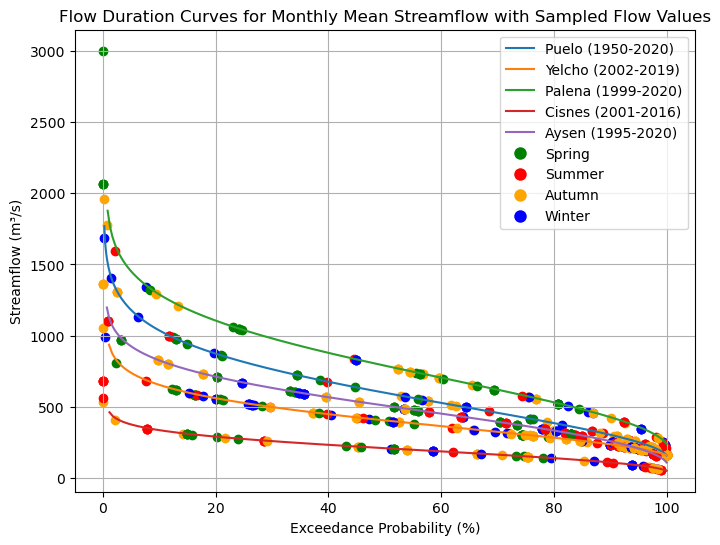

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D

# Load the data from the CSV file
file_path = "../Data/Q_PMETobs_1950_2020_v10d.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])

# Extract only the columns for the rivers of interest
rivers_of_interest = ["X10523002", "X10704002", "X11040001", "X11147001", "X11342001"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a DataFrame with complete date range covering the entire time span of the data
date_range = pd.date_range(start=data['Date'].min(), end=data['Date'].max(), freq='D')
complete_data = pd.DataFrame({'Date': date_range})
complete_data.set_index('Date', inplace=True)

# Load the sampled data
sampled_data_path = "../Data/sampled_dates_flow_complete.xlsx"
sampled_data = pd.read_excel(sampled_data_path)

# Define colors for each season
season_colors = {'Spring': 'green', 'Summer': 'red', 'Autumn': 'orange', 'Winter': 'blue'}

# Plot settings
plt.figure(figsize=(8, 6))
legend_handles = []  # List to store legend handles with line styles

for river_code, river_name in zip(rivers_of_interest, river_names):
    river_data = data[['Date', river_code]].copy()  # Create a copy of the DataFrame
    river_data.set_index('Date', inplace=True)
    merged_data = complete_data.merge(river_data, how='left', left_index=True, right_index=True)
    merged_data.rename(columns={river_code: river_name}, inplace=True)
    
    # Find the year range with actual data (non-NaN values)
    valid_years = merged_data[river_name].dropna().index.year
    min_year = valid_years.min()
    max_year = valid_years.max()
    year_range = f"({min_year}-{max_year})" if not np.isnan(min_year) and not np.isnan(max_year) else "(No Data)"
    
    # Calculate flow duration curve for each river
    flow_values = merged_data.groupby([merged_data.index.year, merged_data.index.month])[river_name].mean().dropna()
    sorted_flow_values = np.sort(flow_values)
    exceedance_probability = np.arange(1, len(flow_values) + 1) / len(flow_values)
    
    # Fit Weibull distribution to the data
    shape, loc, scale = stats.weibull_min.fit(sorted_flow_values, loc=0)
    weibull_fit = stats.weibull_min(shape, loc=loc, scale=scale)
    fitted_flow_values = weibull_fit.ppf(exceedance_probability)
    
    # Plot only the line of best fit for each river
    line, = plt.plot(np.flip(exceedance_probability) * 100, fitted_flow_values, label=f"{river_name} {year_range}")
    legend_handles.append(line)  # Append legend handle with line style
    
    # Plot sampled flow values on the Weibull distribution line
    sampled_river_data = sampled_data[sampled_data['River'] == river_name]
    for _, row in sampled_river_data.iterrows():
        x_value = 100 * (1 - stats.weibull_min.cdf(row['Flow'], shape, loc=loc, scale=scale))
        # Extract month from date
        month = row['Date'].month
        # Define season based on the month
        if month in [9, 10, 11]:
            season = 'Spring: Sep to Nov'
        elif month in [12, 1, 2]:
            season = 'Summer: Dec to Feb'
        elif month in [3, 4, 5]:
            season = 'Autumn: Mar to May'
        else:
            season = 'Winter: Jun to Aug'
        # Assign color based on season
        color = season_colors[season.split(':')[0]]
        plt.scatter(x_value, row['Flow'], color=color, label=season)  # Use color based on season

# Add separate legend entries for the Weibull distribution lines and seasons
legend_seasons = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=season.split(':')[0]) for season, color in season_colors.items()]
legend_handles.extend(legend_seasons)  # Extend the list with legend handles for seasons

# Create a single legend
plt.legend(handles=legend_handles, loc='upper right')

plt.xlabel('Exceedance Probability (%)')
plt.ylabel('Streamflow (m³/s)')
plt.title('Flow Duration Curves for Monthly Mean Streamflow with Sampled Flow Values')
plt.grid(True)

# Save the figure to a folder
plt.savefig("../Figures/fdc_all_rivers_with_sampling.png")

plt.show()